In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

HERE = Path.cwd()

cor_path = HERE / "correlations_skill_luck_decomposition.csv"
disp_path = HERE / "dispersion_skill_luck_decomposition.csv"
upset_path = HERE / "upset_frequency_skill_luck_decomposition.csv"

cor_path, disp_path, upset_path

(PosixPath('/Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/correlations_skill_luck_decomposition.csv'),
 PosixPath('/Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/dispersion_skill_luck_decomposition.csv'),
 PosixPath('/Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/upset_frequency_skill_luck_decomposition.csv'))

In [4]:
df_cor = pd.read_csv(cor_path)
df_disp = pd.read_csv(disp_path)
df_upset = pd.read_csv(upset_path)

In [5]:
# correlations metric - average data over all seasons by league

cor_agg = (
    df_cor
    .groupby("league", as_index=False)[["q_results", "q_goals"]]
    .mean()
)
cor_agg["metric"] = "Correlation of Win Percentages"
cor_agg

,league,q_results,q_goals,metric
0,Bundesliga,0.546857,0.532626,Correlation of Win Percentages
1,La Liga,0.496352,0.495586,Correlation of Win Percentages
2,Premier League,0.634467,0.621174,Correlation of Win Percentages
3,Serie A,0.628867,0.626045,Correlation of Win Percentages


In [6]:
# win dispersion - already averaged across all seasons

disp_agg = df_disp[["league", "q_results", "q_goals"]].copy()
disp_agg["metric"] = "Standard Deviation of Win Rate"
disp_agg

,league,q_results,q_goals,metric
0,Bundesliga,0.293893,0.292635,Standard Deviation of Win Rate
1,La Liga,0.305063,0.306097,Standard Deviation of Win Rate
2,Premier League,0.354750,0.355294,Standard Deviation of Win Rate
3,Serie A,0.348931,0.344366,Standard Deviation of Win Rate


In [7]:
# upset frequency metric - average data over all seasons by league

upset_agg = (
    df_upset
    .groupby("league", as_index=False)[["q_results", "q_goals"]]
    .mean()
)
upset_agg["metric"] = "Upset Frequency"
upset_agg

,league,q_results,q_goals,metric
0,Bundesliga,0.177969,0.137290,Upset Frequency
1,La Liga,0.182185,0.106747,Upset Frequency
2,Premier League,0.226080,0.168480,Upset Frequency
3,Serie A,0.225019,0.160647,Upset Frequency


In [8]:
summary = pd.concat([cor_agg, disp_agg, upset_agg], ignore_index=True)

# compute skill / luck shares (as percentages) for both q value types
summary["skill_results_pct"] = summary["q_results"] * 100
summary["luck_results_pct"] = (1.0 - summary["q_results"]) * 100

summary["skill_goals_pct"] = summary["q_goals"] * 100
summary["luck_goals_pct"] = (1.0 - summary["q_goals"]) * 100

summary

,league,q_results,q_goals,metric,skill_results_pct,luck_results_pct,skill_goals_pct,luck_goals_pct
0,Bundesliga,0.546857,0.532626,Correlation of Win Percentages,54.685733,45.314267,53.262562,46.737438
1,La Liga,0.496352,0.495586,Correlation of Win Percentages,49.635239,50.364761,49.558646,50.441354
2,Premier League,0.634467,0.621174,Correlation of Win Percentages,63.446667,36.553333,62.117446,37.882554
3,Serie A,0.628867,0.626045,Correlation of Win Percentages,62.886732,37.113268,62.604451,37.395549
4,Bundesliga,0.293893,0.292635,Standard Deviation of Win Rate,29.389259,70.610741,29.263547,70.736453
5,La Liga,0.305063,0.306097,Standard Deviation of Win Rate,30.506274,69.493726,30.609724,69.390276
6,Premier League,0.354750,0.355294,Standard Deviation of Win Rate,35.474981,64.525019,35.529413,64.470587
7,Serie A,0.348931,0.344366,Standard Deviation of Win Rate,34.893051,65.106949,34.436630,65.563370
8,Bundesliga,0.177969,0.137290,Upset Frequency,17.796903,82.203097,13.728964,86.271036
9,La Liga,0.182185,0.106747,Upset Frequency,18.218492,81.781508,10.674673,89.325327


In [9]:
out_csv = HERE / "skill_luck_summary_by_metric.csv"
summary.to_csv(out_csv, index=False)
out_csv

PosixPath('/Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/skill_luck_summary_by_metric.csv')

In [10]:
metric_order = [
    "Correlation of Win Percentages",
    "Standard Deviation of Win Rate",
    "Upset Frequency",
]

summary_results = summary.copy()
summary_results["metric"] = pd.Categorical(
    summary_results["metric"],
    categories=metric_order,
    ordered=True,
)

pivot_results = summary_results.pivot(
    index="metric",
    columns="league",
    values="skill_results_pct",
).sort_index()

pivot_results

league,Bundesliga,La Liga,Premier League,Serie A
metric,,,,
Correlation of Win Percentages,54.685733,49.635239,63.446667,62.886732
Standard Deviation of Win Rate,29.389259,30.506274,35.474981,34.893051
Upset Frequency,17.796903,18.218492,22.608039,22.501918


PosixPath('/Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/skill_luck_bar_q_results.png')

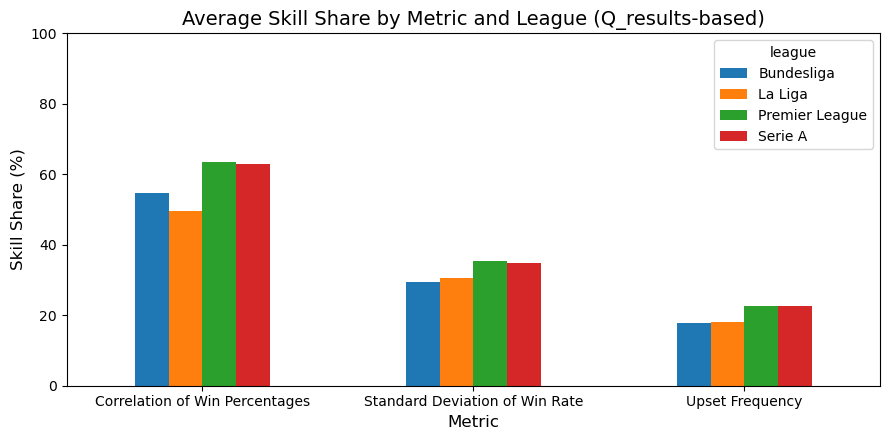

In [11]:
ax = pivot_results.plot(kind="bar")

ax.set_title("Average Skill Share by Metric and League (Q_results-based)")
ax.set_ylabel("Skill Share (%)")
ax.set_xlabel("Metric")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.tight_layout()

results_fig_path = HERE / "skill_luck_bar_q_results.png"
plt.savefig(results_fig_path, dpi=300)
results_fig_path

In [12]:
summary_goals = summary.copy()
summary_goals["metric"] = pd.Categorical(
    summary_goals["metric"],
    categories=metric_order,
    ordered=True,
)

pivot_goals = summary_goals.pivot(
    index="metric",
    columns="league",
    values="skill_goals_pct",
).sort_index()

pivot_goals

league,Bundesliga,La Liga,Premier League,Serie A
metric,,,,
Correlation of Win Percentages,53.262562,49.558646,62.117446,62.604451
Standard Deviation of Win Rate,29.263547,30.609724,35.529413,34.436630
Upset Frequency,13.728964,10.674673,16.848032,16.064732


PosixPath('/Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/skill_luck_bar_q_goals.png')

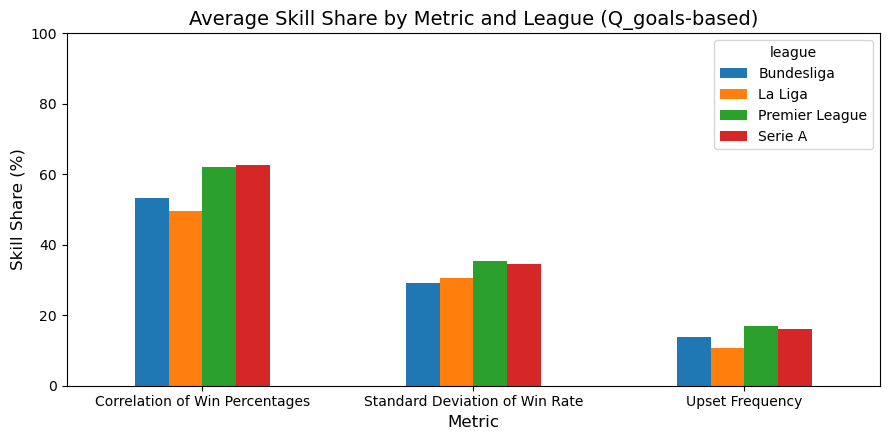

In [13]:
ax = pivot_goals.plot(kind="bar")

ax.set_title("Average Skill Share by Metric and League (Q_goals-based)")
ax.set_ylabel("Skill Share (%)")
ax.set_xlabel("Metric")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.tight_layout()

goals_fig_path = HERE / "skill_luck_bar_q_goals.png"
plt.savefig(goals_fig_path, dpi=300)
goals_fig_path